In [10]:
!pip install -qq japanize-matplotlib
!pip install -qq networkx
!apt-get -y install fonts-ipafont-gothic

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-ipafont-mincho
The following NEW packages will be installed:
  fonts-ipafont-gothic fonts-ipafont-mincho
0 upgraded, 2 newly installed, 0 to remove and 3 not upgraded.
Need to get 8,237 kB of archives.
After this operation, 28.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-ipafont-gothic all 00303-21ubuntu1 [3,513 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-ipafont-mincho all 00303-21ubuntu1 [4,724 kB]
Fetched 8,237 kB in 0s (26.7 MB/s)
Selecting previously unselected package fonts-ipafont-gothic.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-ipafont-gothic_00303-21ubuntu1_all.deb ...
Unpacking fonts-ipafont-gothic (00303-21ubuntu1) ...
Selecting previously unselected package fonts-ipafo

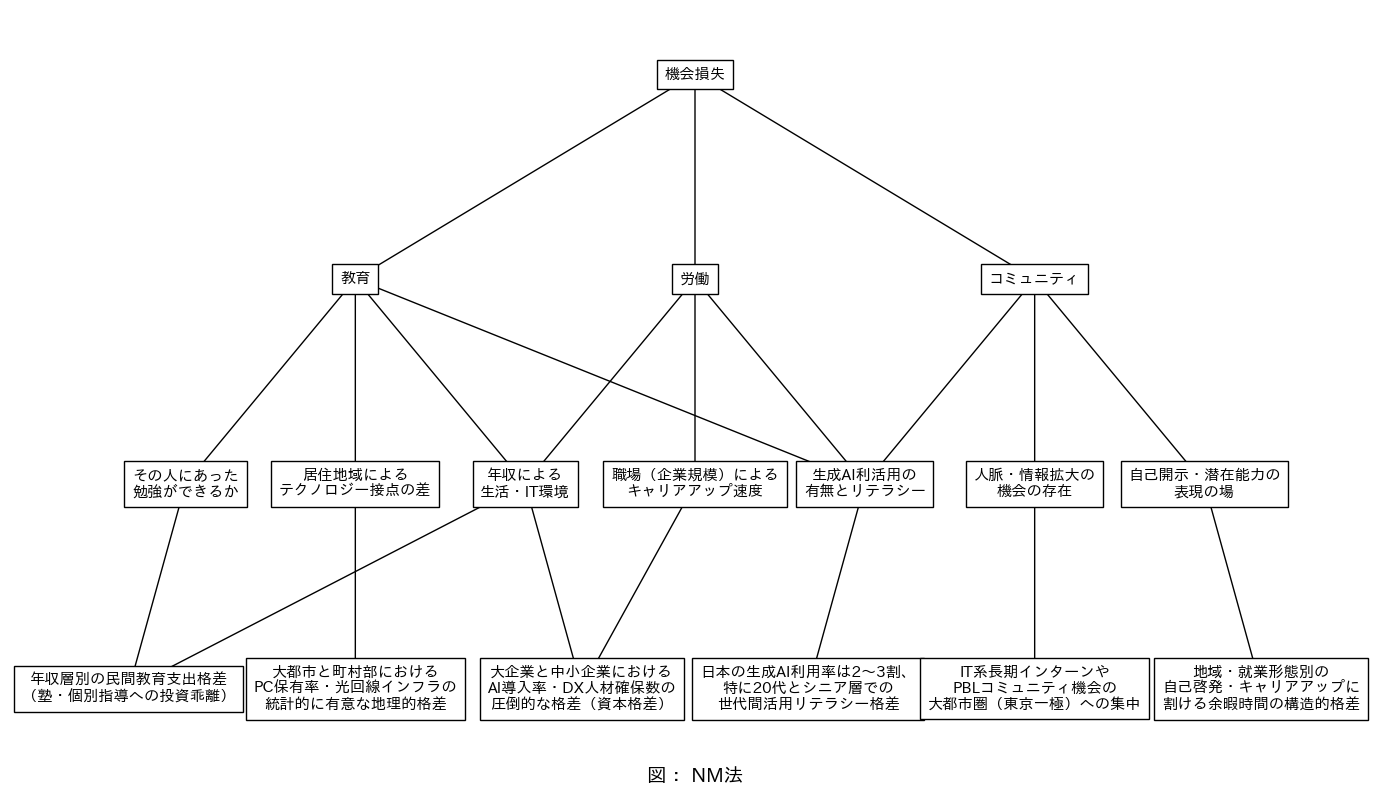

In [24]:
import networkx as nx
import japanize_matplotlib
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'IPAPGothic'
japanize_matplotlib.japanize()

# =====================================================================
# 1. データ定義（Level 3を客観的な統計的事実・事例に置換）
# =====================================================================
# 構造: "ノードID": {"label": "表示文字", "pos": (x, y), "parents": ["親のノードID"]}
idea_data = {
    # Level 0: キーワード
    "root": {"label": "機会損失", "pos": (0, 3), "parents": []},

    # Level 1: 検証領域
    "kanransha": {"label": "教育", "pos": (-3.0, 2), "parents": ["root"]},
    "motor":     {"label": "労働", "pos": (0, 2), "parents": ["root"]},
    "koma":      {"label": "コミュニティ", "pos": (3.0, 2), "parents": ["root"]},

    # Level 2: 背景にある特徴（抽象的なボトルネック）
    "fe_jousoku": {"label": "その人にあった\n勉強ができるか", "pos": (-4.5, 1), "parents": ["kanransha"]},
    "fe_hito":    {"label": "居住地域による\nテクノロジー接点の差", "pos": (-3.0, 1), "parents": ["kanransha"]},
    "fe_jiku":    {"label": "年収による\n生活・IT環境", "pos": (-1.5, 1), "parents": ["kanransha", "motor"]},
    "fe_jiki":    {"label": "職場（企業規模）による\nキャリアアップ速度", "pos": (0, 1), "parents": ["motor"]},
    "fe_kansei":  {"label": "生成AI利活用の\n有無とリテラシー", "pos": (1.5, 1), "parents": ["kanransha", "motor", "koma"]},
    "fe_shaft":   {"label": "人脈・情報拡大の\n機会の存在", "pos": (3.0, 1), "parents": ["koma"]},
    "fe_himo":    {"label": "自己開示・潜在能力の\n表現の場", "pos": (4.5, 1), "parents": ["koma"]},

    # Level 3: 具体的な事例・統計データ（客観的なエビデンス）
    "id_gear":   {"label": "年収層別の民間教育支出格差\n（塾・個別指導への投資乖離）", "pos": (-5, 0), "parents": ["fe_jousoku", "fe_jiku"]},
    "id_record": {"label": "大都市と町村部における\nPC保有率・光回線インフラの\n統計的に有意な地理的格差", "pos": (-3, 0), "parents": ["fe_hito"]},
    "id_stator": {"label": "大企業と中小企業における\nAI導入率・DX人材確保数の\n圧倒的な格差（資本格差）", "pos": (-1, 0), "parents": ["fe_jiku", "fe_jiki"]},
    "id_weight": {"label": "日本の生成AI利用率は2〜3割、\n特に20代とシニア層での\n世代間活用リテラシー格差", "pos": (1, 0), "parents": ["fe_kansei"]},
    "id_rotor":  {"label": "IT系長期インターンや\nPBLコミュニティ機会の\n大都市圏（東京一極）への集中", "pos": (3, 0), "parents": ["fe_shaft"]},
    "id_belt":   {"label": "地域・就業形態別の\n自己啓発・キャリアアップに\n割ける余暇時間の構造的格差", "pos": (5, 0), "parents": ["fe_himo"]}
}

# =====================================================================
# 2. グラフオブジェクトの自動生成ロジック
# =====================================================================
G = nx.DiGraph()
pos = {}
labels = {}

# 統合データからNetworkX用の各配置データを分解・生成
for node_id, info in idea_data.items():
    G.add_node(node_id)
    pos[node_id] = info["pos"]
    labels[node_id] = info["label"]

    # 親IDのリストからエッジを自動生成
    for parent_id in info["parents"]:
        if parent_id in idea_data:  # 親IDが定義されている場合のみエッジを張る
            G.add_edge(parent_id, node_id)

# =====================================================================
# 3. 描画処理
# =====================================================================
plt.figure(figsize=(14, 8))

# 矢印（エッジ）の描画
nx.draw_networkx_edges(
    G, pos,
    arrowstyle="->",
    arrowsize=15,
    edge_color="black",
    node_size=0,
    connectionstyle="arc3,rad=0"
)

# ラベル（テキストボックス）の描画
bbox_props = dict(boxstyle="square,pad=0.5", fc="white", ec="black", lw=1)

nx.draw_networkx_labels(
    G, pos,
    labels=labels,       # 生成したラベル辞書（IDとテキストのマッピング）を適用
    font_size=11,
    font_family="IPAexGothic",
    bbox=bbox_props
)

plt.title("図： NM法", fontsize=14, y=-0.05, fontfamily="IPAexGothic")
plt.axis("off")
plt.tight_layout()

plt.savefig("nm_method_chart_managed.png", dpi=300, bbox_inches="tight")
plt.show()